[<img src="images/colab-badge.png" style="width:16%; vertical-align:middle;">](https://colab.research.google.com/github/fzampirolli/si-md2/blob/main/si-md2/notebooks_alunos/cap02/cap02_aluno.ipynb)
[<img src="images/github-badge.png" style="width:20%; vertical-align:middle;">](https://github.com/fzampirolli/si-md2)

# Mineração de Dados e Regras de Associação

## Introdução

A Mineração de Dados é uma disciplina tão vasta que qualquer publicação
sobre o tema obriga o autor a selecionar alguns tópicos em detrimento de
outros não menos importantes. A atividade de **Regras de Associação**
foi o tópico escolhido para iniciarmos a apresentação das principais
atividades da Mineração de Dados por envolver ideias bem intuitivas. A
analogia entre Regras de Associação e Cesta de Compras facilita o
entendimento de como descobrir padrões de associação entre itens de um
conjunto qualquer.

## Mineração de Dados

Durante o processo de **Descoberta de Conhecimento em Bases de Dados**,
**KDD**, é na etapa de **Mineração de Dados** que efetivamente são
encontrados os padrões de associação implícitos nos dados. A análise
automatizada dessa massa de dados visa detectar regularidades, ou quebra
de regularidade, que constitui informação implícita, porém desconhecida,
e útil para determinado fim.

A Mineração de Dados pode ser vista como a sistematização de teorias,
técnicas e algoritmos desenvolvidos em outras disciplinas já
consagradas, como a Estatística, a Inteligência Artificial, o
Aprendizado de Máquina, a Base de Dados etc. O propósito da Mineração de
Dados é detectar automaticamente padrões de associação úteis e não
óbvios em grandes quantidades de dados, veja [Figura 2.1](#fig-2-1).

No dia a dia, uma quantidade incalculável de dados é gerada na forma de
registros de vendas, textos brutos, imagens, sons, gráficos etc., tanto
por sistemas computacionais como por seres humanos, constituindo uma
espécie de informação não estruturada. Embora esta forma de registro de
dados seja adequada para o ser humano, quando se trata de analisar
grandes quantidades de dados de forma automatizada, é comum e
conveniente que se introduza alguma **estrutura** que facilite o acesso
e o processamento sistemático.

<figure id="fig-2-1" style="text-align:center; margin:1em 0;">
  <img src="images/fig-2-1.png" alt="" style="max-width:60%; display:block; margin:auto;" />
  <figcaption><strong>Figura 2.1:</strong> A Relação da Mineração de Dados com Algumas Disciplinas Correlatas.</figcaption>
</figure>

Para que parte de toda essa informação não estruturada possa ser
utilizada na Mineração de Dados, geralmente é feita uma seleção e um
pré-processamento visando transformar dados brutos em coleções
estruturadas de dados. Em termos práticos, para nossas considerações
iniciais, a estrutura de representação de uma Base de Dados pode ser
semelhante a uma tabela de dados, sendo cada linha dessa tabela uma
**transação** ou um **exemplo**. Cada **transação** é composta por um ou
mais **itens** ou, visto de outra forma, cada **exemplo** é
caracterizado por seus **atributos**.

As Tabelas [2.1](#tbl-2-cestas), [2.2](#tbl-2-booleana) e [2.3](#tbl-2-tempo) ilustram formas de dados estruturados convenientes para a Mineração de Dados.

In [1]:
# @title { display-mode: "form" }
import pandas as pd
from IPython.display import Markdown

dados = {
    'TID': [1, 2, 3, 4, 5],
    'Itens': [
        '{Arroz, Feijão, Óleo}',
        '{Queijo, Vinho}',
        '{Arroz, Feijão, Batata, Óleo}',
        '{Arroz, Água, Queijo, Vinho}',
        '{Arroz, Feijão, Batata, Óleo}'
    ]
}
df = pd.DataFrame(dados)

# Para garantir que o Quarto entenda como Markdown puro e o Colab mostre formatado:
Markdown(df.to_markdown(index=False, colalign=("center", "left")))

**Tabela 2.1:** Cestas de Compras.


|  TID  | Itens                         |
|:-----:|:------------------------------|
|   1   | {Arroz, Feijão, Óleo}         |
|   2   | {Queijo, Vinho}               |
|   3   | {Arroz, Feijão, Batata, Óleo} |
|   4   | {Arroz, Água, Queijo, Vinho}  |
|   5   | {Arroz, Feijão, Batata, Óleo} |

Na [Tabela 2.1](#tbl-2-cestas) cada uma das Transações possui uma IDentificação (TID), e
seus itens representam artigos vendidos em um supermercado. Se a tabela
de itens for muito extensa, como costuma ser em casos reais, pode ser
ainda mais conveniente representar cada um de seus itens na forma de um
atributo associado a um valor booleano, como mostra a [Tabela 2.2](#tbl-2-booleana).


In [2]:
# @title { display-mode: "form" }
import pandas as pd
from IPython.display import Markdown

dados_booleana = {
    'TID': [1, 2, 3, 4, 5],
    'Arroz': ['y', 'n', 'y', 'y', 'y'],
    'Feijão': ['y', 'n', 'y', 'n', 'y'],
    'Batata': ['n', 'n', 'y', 'n', 'y'],
    'Óleo': ['y', 'n', 'y', 'n', 'y'],
    'Água': ['n', 'n', 'n', 'y', 'n'],
    'Queijo': ['n', 'y', 'n', 'y', 'n'],
    'Vinho': ['n', 'y', 'n', 'y', 'n']
}
df_booleana = pd.DataFrame(dados_booleana)

Markdown(df_booleana.to_markdown(index=False, colalign=("center",) * len(df_booleana.columns)))

**Tabela 2.2:** Representação Booleana de Cestas de Compras.


|  TID  |  Arroz  |  Feijão  |  Batata  |  Óleo  |  Água  |  Queijo  |  Vinho  |
|:-----:|:-------:|:--------:|:--------:|:------:|:------:|:--------:|:-------:|
|   1   |    y    |    y     |    n     |   y    |   n    |    n     |    n    |
|   2   |    n    |    n     |    n     |   n    |   n    |    y     |    y    |
|   3   |    y    |    y     |    y     |   y    |   n    |    n     |    n    |
|   4   |    y    |    n     |    n     |   n    |   y    |    y     |    y    |
|   5   |    y    |    y     |    y     |   y    |   n    |    n     |    n    |

Um exemplo clássico de uma Base de Dados usada em artigos sobre
Mineração de Dados é apresentada na [Tabela 2.3](#tbl-2-tempo) (Quinlan (1986) *apud*  Witten e Frank (2005)), composta por dados fictícios sobre as condições
de tempo para que ocorra ou não a partida de um esporte não
especificado. A tabela é composta por 14 exemplos (linhas), cada um com
cinco atributos (colunas): Dia, Temperatura, Umidade, Vento e Partida. A
tabela pode também ser interpretada de outra forma, como sendo composta
por quatro atributos (Dia, Temperatura, Umidade e Vento) e uma classe
(Partida), que representa o resultado da combinação dos quatro
atributos.

In [3]:
# @title { display-mode: "form" }
import pandas as pd
from IPython.display import Markdown

dados_tempo = {
    'Dia': ['Ensolarado', 'Ensolarado', 'Nublado', 'Chuvoso', 'Chuvoso', 'Chuvoso', 'Nublado', 'Ensolarado', 'Ensolarado', 'Chuvoso', 'Ensolarado', 'Nublado', 'Nublado', 'Chuvoso'],
    'Temperatura': ['Elevada', 'Elevada', 'Elevada', 'Amena', 'Baixa', 'Baixa', 'Baixa', 'Amena', 'Baixa', 'Amena', 'Amena', 'Amena', 'Elevada', 'Amena'],
    'Umidade': ['Alta', 'Alta', 'Alta', 'Alta', 'Normal', 'Normal', 'Normal', 'Alta', 'Normal', 'Normal', 'Normal', 'Alta', 'Normal', 'Alta'],
    'Vento': ['Falso', 'Verdadeiro', 'Falso', 'Falso', 'Falso', 'Verdadeiro', 'Verdadeiro', 'Falso', 'Falso', 'Falso', 'Verdadeiro', 'Verdadeiro', 'Falso', 'Verdadeiro'],
    'Partida': ['Não', 'Não', 'Sim', 'Sim', 'Sim', 'Não', 'Sim', 'Não', 'Sim', 'Sim', 'Sim', 'Sim', 'Sim', 'Não']
}
df_tempo = pd.DataFrame(dados_tempo)

Markdown(df_tempo.to_markdown(index=False))

**Tabela 2.3:** Tabela do Tempo.


| Dia        | Temperatura   | Umidade   | Vento      | Partida   |
|:-----------|:--------------|:----------|:-----------|:----------|
| Ensolarado | Elevada       | Alta      | Falso      | Não       |
| Ensolarado | Elevada       | Alta      | Verdadeiro | Não       |
| Nublado    | Elevada       | Alta      | Falso      | Sim       |
| Chuvoso    | Amena         | Alta      | Falso      | Sim       |
| Chuvoso    | Baixa         | Normal    | Falso      | Sim       |
| Chuvoso    | Baixa         | Normal    | Verdadeiro | Não       |
| Nublado    | Baixa         | Normal    | Verdadeiro | Sim       |
| Ensolarado | Amena         | Alta      | Falso      | Não       |
| Ensolarado | Baixa         | Normal    | Falso      | Sim       |
| Chuvoso    | Amena         | Normal    | Falso      | Sim       |
| Ensolarado | Amena         | Normal    | Verdadeiro | Sim       |
| Nublado    | Amena         | Alta      | Verdadeiro | Sim       |
| Nublado    | Elevada       | Normal    | Falso      | Sim       |
| Chuvoso    | Amena         | Alta      | Verdadeiro | Não       |

Uma análise mais atenta dos exemplos das Tabelas [2.1](#tbl-2-cestas) e [2.3](#tbl-2-tempo) revela que alguns desses atributos sempre aparecem juntos e que, portanto, várias
**Regras de Associação** podem ser extraídas dessas tabelas.

## Regras de Associação 

A representação do conhecimento através de regras, também conhecidas
como regras *IF-THEN* ou Regras de Produção, é largamente utilizada
porque, entre outras vantagens sobre formas alternativas de
representação do conhecimento, regras são facilmente compreendidas pelo ser
humano, fáceis de serem alteradas, validadas e verificadas, e de baixo
custo para a criação de sistemas baseados em regras (Padhy (2010)).

${\color{blue}{\textbf{Regras de Associação}}}$ são uma forma específica de representação de
conhecimento que descrevem padrões de associação implícitos entre um
conjunto de atributos ou itens de uma Base de Dados, e que podem ajudar
a predizer com alta probabilidade a presença, ou não, de outro conjunto
de atributos ou itens.

Dito de forma equivalente, uma Regra de Associação revela que a presença
de um conjunto $\mathbf{X}$ de itens numa transação implica outro conjunto
$\mathbf{Y}$ de itens, i.e., $\mathbf{X} = \{a, b, \ldots\} \Rightarrow \mathbf{Y} = \{p, \ldots, z\}$.
Note que o fato de um conjunto de itens $\mathbf{X}$ (antecedente) estar sempre
associado a outro $\mathbf{Y}$ (consequente) não significa obrigatoriamente que
um seja a causa de outro, i.e., não há necessariamente relação de
causalidade entre antecedente e consequente e sim mera ocorrência
simultânea de itens com certa probabilidade.


A estrutura geral de uma **Regra de Associação** assume a seguinte forma:

$$
{\color{red}{\textbf{If }}} 
(\text{Conjunto } \mathbf{X} \text{ de Itens})
\;{\color{red}{\textbf{ then }}}\;
(\text{Conjunto } \mathbf{Y} \text{ de Itens}),
\quad \text{sendo } \mathbf{X} \cap \mathbf{Y} = \varnothing
$$ 



Com base na [Tabela 2.3](#tbl-2-tempo), várias Regras de Associação podem ser
formuladas:

<a id="eq-2-1"></a>
$$
{\color{red}{\textbf{If }}} 
(\text{Temperatura} = \text{Baixa})
\;{\color{red}{\textbf{ then }}}\;
(\text{Umidade} = \text{Normal}) \tag{2.1}
$$




<a id="eq-2-2"></a>
$$
{\color{red}{\textbf{If }}} 
(\text{Umidade} = \text{Normal})
\;{\color{red}{\textbf{ and }}}\;
(\text{Vento} = \text{Falso})
\;{\color{red}{\textbf{ then }}}\;
(\text{Partida} = \text{Sim}) \tag{2.2}
$$




<a id="eq-2-3"></a>
$$
{\color{red}{\textbf{If }}} 
(\text{Dia} = \text{Ensolarado})
\;{\color{red}{\textbf{ and }}}\;
(\text{Partida} = \text{Não})
\;{\color{red}{\textbf{ then }}}\;
(\text{Umidade} = \text{Alta}) \tag{2.3}
$$




<a id="eq-2-4"></a>
$$
{\color{red}{\textbf{If }}} 
(\text{Vento} = \text{Falso})
\;{\color{red}{\textbf{ and }}}\;
(\text{Partida} = \text{Não})
\;{\color{red}{\textbf{ then }}}\;
(\text{Temperatura} = \text{Elevada})
\;{\color{red}{\textbf{ and }}}\;
(\text{Umidade} = \text{Alta}) \tag{2.4}
$$



Estas são apenas algumas das muitas Regras de Associação que podem ser
formuladas com base na [Tabela 2.3](#tbl-2-tempo). Para selecionar as Regras de
Associação mais representativas, i.e., aquelas que se apliquem a um
grande número de exemplos com alta probabilidade de acerto, precisaremos
de métricas para avaliar o alcance ou a força de cada regra. Dois dos
mais conhecidos indicadores são **Suporte** e **Confiança**.

**Suporte** --- para cada regra do tipo $\mathbf{X} \Rightarrow \mathbf{Y}$, este parâmetro indica
a quantos exemplos da tabela esta regra satisfaz (i.e., contém) tanto ao
conjunto de itens de $\mathbf{X}$ quanto ao de $\mathbf{Y}$, ou seja, indica sua
**cobertura** com relação ao número total $N$ de exemplos da tabela.
Portanto,

$$\mathbf{\mathbf{Sup}}\left( \mathbf{X \rightarrow Y} \right)\mathbf{=}\frac{\mathbf{|X \cup Y|}}{\mathbf{N}}$$

Por exemplo, com relação à primeira [Regra 2.1](#eq-2-1), há quatro exemplos na [Tabela 2.3](#tbl-2-tempo) em que 
$\mathbf{X} \cup \mathbf{Y} = \{\text{Temperatura} = \text{Baixa},\; \text{Umidade} = \text{Normal}\}$.
Portanto,

$$
\mathbf{Sup}\left( \text{Regra 2.1} \right) 
= \frac{\left| X \cup Y \right|}{N} 
= \frac{\left| \left\{ \text{Temperatura = Baixa, Umidade = Normal} \right\} \right|}{N} 
= \frac{4}{14} = 0{,}29
$$


A [Regra 2.2](#eq-2-2) também possui 
$\mathbf{Sup}(\text{Regra 2.2}) = \frac{4}{14}$; 
a terceira regra apresenta 
$\mathbf{Sup}(\text{Regra 2.3}) = \frac{3}{14}$, 
enquanto a quarta regra possui 
$\mathbf{Sup}(\text{Regra 2.4}) = \frac{1}{14}$.



**Confiança** --- a confiança de uma regra reflete o número de exemplos que contêm $\mathbf{Y}$ dentre todos aqueles que contêm $\mathbf{X}$ (veja bem, além de $\mathbf{X} \Rightarrow \mathbf{Y}$, podem existir regras do tipo $\mathbf{X} \Rightarrow \mathbf{Z}$, $\mathbf{X} \Rightarrow \mathbf{W}$ etc.). Em outras palavras, o parâmetro Confiança determina quantos são os exemplos em que $\mathbf{X}$ implica $\mathbf{Y}$, comparado com aqueles exemplos em que $\mathbf{X}$ pode ou não implicar $\mathbf{Y}$. A este parâmetro costuma-se também dar o nome de $\mathbf{Acurácia}$.

$$
\mathbf{Conf}\!\left(\mathbf{X} \Rightarrow \mathbf{Y}\right)
=
\frac{\left| \mathbf{X} \cup \mathbf{Y} \right|}
     {\left| \mathbf{X} \right|}
=
\frac{\mathbf{Sup}\!\left(\mathbf{X} \Rightarrow \mathbf{Y}\right)}
     {\mathbf{Sup}\!\left(\mathbf{X}\right)}
$$

Por exemplo, com relação à primeira [Regra 2.1](#eq-2-1), há quatro exemplos na [Tabela 2.3](#tbl-2-tempo) em que $\mathbf{X} \cup \mathbf{Y} = \{\text{Temperatura} = \text{Baixa},\; \text{Umidade} = \text{Normal}\}$ e, coincidentemente, quatro exemplos em que $\mathbf{X} = \{\text{Temperatura} = \text{Baixa}\}$. Portanto,

$$
\mathbf{Conf}\!\left(\text{Regra 2.1}\right)
=
\frac{\left| \mathbf{X} \cup \mathbf{Y} \right|}{\left| \mathbf{X} \right|}
=
\frac{\left| \{\text{Temperatura} = \text{Baixa},\; \text{Umidade} = \text{Normal}\} \right|}
     {\left| \{\text{Temperatura} = \text{Baixa}\} \right|}
=
\frac{4}{4}
=
1{,}0
$$

A [Regra 2.2](#eq-2-2) também possui $\mathbf{Conf}\!\left(\text{Regra 2.2}\right) = \frac{4}{4}$; a terceira regra apresenta $\mathbf{Conf}\!\left(\text{Regra 2.3}\right) = \frac{3}{3}$, enquanto a quarta regra possui $\mathbf{Conf}\!\left(\text{Regra 2.4}\right) = \frac{1}{2}$.



> ### 📝 Nota sobre notação: $|\cdot|$
>
> Seguindo a convenção de Agrawal et al. (1993) e Han e Kamber (2008),
> o símbolo $|\cdot|$ nessas fórmulas **não** representa a cardinalidade
> matemática do conjunto (número de itens), mas sim a **frequência
> absoluta** — ou seja, o número de transações da base de dados que
> contêm aquele conjunto de itens. Assim, $|\mathbf{X}|$ significa
> "quantas transações contêm todos os itens de $\mathbf{X}$",
> equivalente a $\mathbf{Sup}(\mathbf{X}) \times N$.

Regras de Associação são particularmente úteis para analisar o
comportamento de clientes e propor "vendas casadas". A informação de que
clientes que compram o item A geralmente compram o item B pode aumentar
significativamente as vendas de uma loja ou livraria, já que toda vez
que um cliente manifestar a intenção de comprar o item A, a loja pode
também lhe oferecer o item B.

Mas o fato de um simples conjunto de itens poder gerar muitas regras de
associação faz com que o número de regras associadas a uma base de dados
seja tão grande a ponto de a maioria dessas regras não ter qualquer
interesse prático. Para contornar esta situação, antes de começar a
gerar as regras de associação, é comum que sejam estabelecidos um valor
de Suporte Mínimo ($\mathbf{SupMin}$) e de Confiança Mínima ($\mathbf{ConfMin}$).
Regras com suporte muito baixo podem ser resultado de compras feitas ao
acaso e, portanto, não fornecem informações de interesse. Por outro
lado, regras com confiança muito baixa podem indicar que seu poder de
predição é baixo e, portanto, não é muito aconselhável assumir que $\mathbf{X}$
implica $\mathbf{Y}$ com base nessas regras.


Agrawal et al. (1993) ao introduzir o conceito de Regras de
Associação propôs um algoritmo denominado **Apriori** no qual Regras de
Associação são geradas em duas etapas:

-   Dado um conjunto de transações **T**, primeiramente são criados
    conjuntos de itens frequentes, chamados de **Conjuntos
    Frequentes**, que devem satisfazer o limite de $\mathbf{SupMin}$;

-   a partir desses Conjuntos Frequentes são geradas **Regras de
    Associação** com confiança maior ou igual **ConfMin**.

## Etapa 1: Geração de Conjuntos Frequentes com Suporte $\geq \mathbf{SupMin}$

As Tabelas [2.4](#tbl-2-simplificada) e [2.5](#tbl-2-alternativa)  mostram versões simplificadas da [Tabela 2.2](#tbl-2-booleana), aqui
adaptada para que cada item possa ser representado por apenas uma letra.


<table style="width:100%; border:none; border-collapse:collapse;"><tr style="border:none;">
<td style="vertical-align:top; padding:4px; width:50%; border:none;"><a id="tbl-2-simplificada"></a>
<div style="text-align:left; font-size:0.9em; margin-bottom:4px;"><strong>Tabela 2.4:</strong> Versão simplificada da <a href="#tbl-2-booleana">Tabela 2.2</a>.</div>

| TID | A | B | C | D | E | F | G |
|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|
| 1 | 1 | 1 | 0 | 1 | 0 | 0 | 0 |
| 2 | 0 | 0 | 0 | 0 | 0 | 1 | 1 |
| 3 | 1 | 1 | 1 | 1 | 0 | 0 | 0 |
| 4 | 1 | 0 | 0 | 0 | 1 | 1 | 1 |
| 5 | 1 | 1 | 1 | 1 | 0 | 0 | 0 |

</td>
<td style="vertical-align:top; padding:4px; width:50%; border:none;"><a id="tbl-2-alternativa"></a>
<div style="text-align:left; font-size:0.9em; margin-bottom:4px;"><strong>Tabela 2.5:</strong> Versão alternativa da <a href="#tbl-2-booleana">Tabela 2.2</a>.</div>

| TID | Itens |
|:---:|:------|
| 1 | {A, B, D} |
| 2 | {F, G} |
| 3 | {A, B, C, D} |
| 4 | {A, E, F, G} |
| 5 | {A, B, C, D} |

</td>
</tr></table>

De acordo com o algoritmo Apriori, para se obter os possíveis Conjuntos
Frequentes relacionados a um conjunto de transações, inicialmente devem
ser criados Conjuntos Frequentes com 1 item apenas e que satisfaçam o
critério de Suporte Mínimo. A seguir são criados recursivamente
Conjuntos Frequentes com 2 itens, depois com 3 itens, e assim
sucessivamente.

Os possíveis Conjuntos Frequentes com 1 item apenas, e seus respectivos
valores de Suporte, estão representados na [Tabela 2.6](#tbl-2-frequentes-1).

<a id="tbl-2-frequentes-1"></a>

**Tabela 2.6:** Possíveis Conjuntos Frequentes com 1 Item.

| Itens | Suporte |
|:-----:|:-------:|
| {A} | 4/5 |
| {B} | 3/5 |
| {C} | 2/5 |
| {D} | 3/5 |
| {E} | 1/5 |
| {F} | 2/5 |
| {G} | 2/5 |


Suponhamos que o $\mathbf{SupMin}$ tenha sido definido como $2/5$, ou seja, $40\%$.
De acordo com este critério, o conjunto {E} não satisfaz $\mathbf{SupMin}$ e
deve ser eliminado. Portanto os Conjuntos Frequentes com 1 Item que
satisfazem o critério de $\mathbf{SupMin}$ maior ou igual a $2/5$ estão
representados na [Tabela 2.7](#tbl-2-frequentes-1-supmin).


Ao adotar o procedimento de poda dos candidatos a Conjunto Frequente que
não satisfazem o critério de $\mathbf{SupMin}$, o número total de
Conjuntos Frequentes gerados pode cair significativamente. Em princípio,
dada uma Base de Dados com $k$ itens, o número de possíveis Conjuntos
Frequentes é $\lvert \mathbf{CF} \rvert = 2^{k} - 1$ (excluindo o conjunto vazio).
Como em nossa [Tabela 2.4](#tbl-2-simplificada) há 7 itens, então
$\lvert \mathbf{CF} \rvert = 2^{7} - 1 = 127$.



<a id="tbl-2-frequentes-1-supmin"></a>

**Tabela 2.7:** Conjuntos Frequentes com 1 Item e $\mathbf{SupMin} \geq \frac{2}{5}$.

| Itens | Suporte |
|:-----:|:-------:|
| {A} | 4/5 |
| {B} | 3/5 |
| {C} | 2/5 |
| {D} | 3/5 |
| {F} | 2/5 |
| {G} | 2/5 |



A seguir devem ser formados novos Conjuntos Frequentes com 2 Itens,
partindo-se dos Conjuntos Frequentes com 1 Item. Note que o Suporte de
um Conjunto Frequente com 2 Itens pode ter no máximo o menor valor de
Suporte de cada um de seus subconjuntos, i. e., dos respectivos
Conjuntos Frequentes com 1 Item. De acordo com esta mesma propriedade,
conhecida como **Princípio Apriori** ou antimonotônico, qualquer
subconjunto de um Conjunto Frequente também será um Conjunto Frequente.
Por exemplo, se $\{A, B\}$ for um Conjunto Frequente, então $\{A\}$ e $\{B\}$ também
são Conjuntos Frequentes e têm $\mathbf{Suporte} \geq \mathbf{SupMin}$.

A [Tabela 2.8](#tbl-2-frequentes-2) mostra os possíveis Conjuntos Frequentes com 2 Itens e os
respectivos valores de Suporte.

Os conjuntos de 2 itens foram obtidos por combinação dos conjuntos de 1
item, enquanto que os valores de Suporte foram obtidos inspecionando-se
as Tabelas [2.4](#tbl-2-simplificada) e [2.5](#tbl-2-alternativa).

Note que os detalhes de como os conjuntos de itens são efetivamente
gerados dependem da forma como o algoritmo Apriori foi implementado, e
diferem um pouco da exposição simplificada que se adotou aqui por razões
didáticas.

Para calcular o Suporte dos Conjuntos Frequentes foi necessário ler a
Base de Dados, que em nosso caso é pequena e está representada pela
[Tabela 2.4](#tbl-2-simplificada). Em uma implementação computacional é altamente desejável que
toda a Base de Dados possa ser lida na memória principal do computador.
Porém, se a Base de Dados for muito grande ela provavelmente terá de ser
lida no disco rígido. Para minimizar o número de vezes que a Base de
Dados é consultada, muitos candidatos a Conjuntos Frequentes podem ser
inicialmente criados e depois eliminados, obtendo-se assim
significativos ganhos de tempo.

<a id="tbl-2-frequentes-2"></a>

**Tabela 2.8:** Possíveis Conjuntos Frequentes com 2 Itens.

| Itens | Suporte |
|:-----:|:-------:|
| {A, B} | 3/5 |
| {A, C} | 2/5 |
| {A, D} | 3/5 |
| {A, F} | 1/5 |
| {A, G} | 1/5 |
| {B, C} | 2/5 |
| {B, D} | 3/5 |
| {B, F} | 0 |
| {B, G} | 0 |
| {C, D} | 2/5 |
| {C, F} | 0 |
| {C, G} | 0 |
| {D, F} | 0 |
| {D, G} | 0 |
| {F, G} | 2/5 |


Para nós, neste momento, o importante é compreender como os Conjuntos
Frequentes com $k$ Itens podem ser gerados de forma relativamente
simples pela combinação de Conjuntos Frequentes com $k-1$ Itens.

Aplicando-se novamente o critério de $\mathbf{SupMin} \geq \frac{2}{5}$,
restam apenas os Conjuntos Frequentes com 2 Itens apresentados na
[Tabela 2.9](#tbl-2-frequentes-supmin).


<a id="tbl-2-frequentes-supmin"></a>

**Tabela 2.9:** Conjuntos Frequentes com 2 Itens e 
$\mathbf{SupMin} \geq \frac{2}{5}$.

| Itens | Suporte |
|:-----:|:-------:|
| {A, B} | 3/5 |
| {A, C} | 2/5 |
| {A, D} | 3/5 |
| {B, C} | 2/5 |
| {B, D} | 3/5 |
| {C, D} | 2/5 |
| {F, G} | 2/5 |




O próximo passo agora consiste em criar novos Conjuntos Frequentes com 3
Itens, partindo-se dos Conjuntos Frequentes com 2 Itens, cujo resultado
é mostrado na [Tabela 2.10](#tbl-2-frequentes-3).

<a id="tbl-2-frequentes-3"></a>

**Tabela 2.10:** Possíveis Conjuntos Frequentes com 3 Itens.

| Itens | Suporte |
|:-----:|:-------:|
| {A, B, C} | 2/5 |
| {A, B, D} | 3/5 |
| {A, C, D} | 2/5 |
| {A, F, G} | 1/5 |
| {B, C, D} | 2/5 |
| {B, F, G} | 0 |
| {C, D, F} | 0 |
| {C, F, G} | 0 |


Neste caso, novamente, alguns Conjuntos Frequentes não satisfazem o
critério de $\mathbf{SupMin} \geq \frac{2}{5}$, havendo a necessidade de
poda para que esses conjuntos não participem da etapa seguinte.

<a id="tbl-2-frequentes-3-supmin"></a>

**Tabela 2.11:** Conjuntos Frequentes com 3 Itens e 
$\mathbf{SupMin} \geq \frac{2}{5}$.

| Itens | Suporte |
|:-----:|:-------:|
| {A, B, C} | 2/5 |
| {A, B, D} | 3/5 |
| {A, C, D} | 2/5 |
| {B, C, D} | 2/5 |


Vamos agora gerar novos Conjuntos Frequentes com 4 Itens, partindo-se
dos Conjuntos Frequentes com 3 Itens ([Tabela 2.11](#tbl-2-frequentes-3-supmin)), cujo resultado é
mostrado na [Tabela 2.12](#tbl-2-frequentes-4).

<a id="tbl-2-frequentes-4"></a>

**Tabela 2.12:** Possíveis Conjuntos Frequentes com 4 Itens.

| Itens | Suporte |
|:-----:|:-------:|
| {A, B, C, D} | 2/5 |


Se houvesse ao menos dois Conjuntos Frequentes com 4 Itens poderíamos
ainda tentar gerar Conjuntos Frequentes com 5 Itens. Mas como há apenas
um Conjunto Frequente com 4 Itens, esta primeira etapa do algoritmo
Apriori termina aqui.







## Etapa 2: Geração de Regra de Associação a partir dos Conjuntos Frequentes

Uma vez obtidos os Conjuntos Frequentes com Suporte 
$\geq \mathbf{SupMin}$, é possível extrair de cada Conjunto Frequente
com $k$ itens um total de $2^{k} - 2$ Regras de Associação
(excluindo-se o conjunto vazio na posição de antecedente 
$\varnothing \Rightarrow \mathbf{CF}$ ou de consequente 
$\mathbf{CF} \Rightarrow \varnothing$). 
Na Etapa 1 foram gerados os seguintes Conjuntos Frequentes:


**Conjuntos Frequentes com 1 Item (total de 6 $\mathbf{CFs}$)**

$$
\{A\},\; \{B\},\; \{C\},\; \{D\},\; \{F\},\; \{G\}
$$

**Conjuntos Frequentes com 2 Itens (total de 7 $\mathbf{CFs}$)**

$$
\{A, B\},\; \{A, C\},\; \{A, D\},\; \{B, C\},\; \{B, D\},\; \{C, D\},\; \{F, G\}
$$

**Conjuntos Frequentes com 3 Itens (total de 4 $\mathbf{CFs}$)**

$$
\{A, B, C\},\; \{A, B, D\},\; \{A, C, D\},\; \{B, C, D\}
$$

**Conjunto Frequente com 4 Itens (total de 1 $\mathbf{CF}$)**

$$
\{A, B, C, D\}
$$



Para extrair as Regras de Associação de um Conjunto Frequente é
necessário, primeiramente, gerar todos os subconjuntos não vazios desse
Conjunto Frequente $\mathbf{CF}$ e, para cada subconjunto
$\mathbf{S} \subset \mathbf{CF}$, produzir uma Regra de Associação do tipo
$\mathbf{S} \Rightarrow (\mathbf{CF} - \mathbf{S})$ que satisfaça o
critério de $\mathbf{Confiança} \geq \mathbf{ConfMin}$.

Por exemplo, dado $\mathbf{CF} = \{A, B, C\}$, seus subconjuntos não vazios
possíveis são
$\mathbf{S} = \{\{A\}, \{B\}, \{C\}, \{A, B\}, \{A, C\},$ $\{B, C\}\}$.
Portanto, é possível extrair seis Regras de Associação do
$\mathbf{CF} = \{A, B, C\}$ que envolvam os três itens:

$$
\{A\} \Rightarrow \{B, C\},
$$

$$
\{B\} \Rightarrow \{A, C\},
$$

$$
\{C\} \Rightarrow \{A, B\},
$$

$$
\{A, B\} \Rightarrow \{C\},
$$

$$
\{A, C\} \Rightarrow \{B\},
$$

$$
\{B, C\} \Rightarrow \{A\}.
$$






Como o Suporte de todos os subconjuntos já terá sido calculado na Etapa 1,
não será necessário percorrer novamente a Base de Dados para calcular
a Confiança de cada Regra de Associação. Basta reutilizar esses valores
já calculados, pois

$$
\mathbf{Conf}\!\left( \mathbf{S} \rightarrow \mathbf{CF} - \mathbf{S} \right)
=
\frac{\left| \mathbf{S} \cup (\mathbf{CF} - \mathbf{S}) \right|}
     {\left| \mathbf{S} \right|}
=
\frac{\left| \mathbf{CF} \right|}
     {\left| \mathbf{S} \right|}
=
\frac{\mathbf{Sup}\!\left( \mathbf{CF} \right)}
     {\mathbf{Sup}\!\left( \mathbf{S} \right)}
$$



Voltando ao exemplo inicial da [Tabela 2.5](#tbl-2-alternativa), como o Suporte de
$\mathbf{CF} = \{A, B, C\}$ é $\frac{2}{5}$ (veja [Tabela 2.11](#tbl-2-frequentes-3-supmin)), e
considerando os Suportes de seus subconjuntos,

<div style="text-align:center;">

$\mathbf{Sup}(\{A\}) = \frac{4}{5} \quad$ (veja [Tabela 2.6](#tbl-2-frequentes-1))

$\mathbf{Sup}(\{B\}) = \frac{3}{5} \quad$ (veja [Tabela 2.6](#tbl-2-frequentes-1))

$\mathbf{Sup}(\{C\}) = \frac{2}{5} \quad$ (veja [Tabela 2.6](#tbl-2-frequentes-1))

$\mathbf{Sup}(\{A, B\}) = \frac{3}{5} \quad$ (veja [Tabela 2.8](#tbl-2-frequentes-2))

$\mathbf{Sup}(\{A, C\}) = \frac{2}{5} \quad$ (veja [Tabela 2.8](#tbl-2-frequentes-2))

$\mathbf{Sup}(\{B, C\}) = \frac{2}{5} \quad$ (veja [Tabela 2.8](#tbl-2-frequentes-2))

</div>

<br>
<p>a Confiança de cada uma das seis regras possíveis será:</p>

$$
\mathbf{Conf}(A \Rightarrow B, C)
=
\frac{\frac{2}{5}}{\frac{4}{5}}
=
0{,}50
$$

$$
\mathbf{Conf}(B \Rightarrow A, C)
=
\frac{\frac{2}{5}}{\frac{3}{5}}
=
0{,}66
$$

$$
\mathbf{Conf}(C \Rightarrow A, B)
=
\frac{\frac{2}{5}}{\frac{2}{5}}
=
1{,}00
$$

$$
\mathbf{Conf}(A, B \Rightarrow C)
=
\frac{\frac{2}{5}}{\frac{3}{5}}
=
0{,}66
$$

$$
\mathbf{Conf}(A, C \Rightarrow B)
=
\frac{\frac{2}{5}}{\frac{2}{5}}
=
1{,}00
$$

$$
\mathbf{Conf}(B, C \Rightarrow A)
=
\frac{\frac{2}{5}}{\frac{2}{5}}
=
1{,}00
$$

Suponha que, para o problema em questão, tenham sido adotados
$\mathbf{SupMin} = 40\%$ e $\mathbf{ConfMin} = 90\%$.
Nesse caso, apenas três das regras acima seriam aproveitadas:

$$
\mathbf{Conf}(C \Rightarrow A, B) = 1{,}00
\quad
\{Batata\} \Rightarrow \{Arroz, Feijão\}
$$

$$
\mathbf{Conf}(A, C \Rightarrow B) = 1{,}00
\quad
\{Arroz, Batata\} \Rightarrow \{Feijão\}
$$

$$
\mathbf{Conf}(B, C \Rightarrow A) = 1{,}00
\quad
\{Feijão, Batata\} \Rightarrow \{Arroz\}
$$

Aplicando-se o procedimento explicado acima para todos os 18
$\mathbf{CFs}$ obtidos na Etapa 1, seriam geradas aproximadamente
30 Regras de Associação com $\mathbf{SupMin} = 40\%$ e
$\mathbf{ConfMin} = 90\%$ (na realidade, chegamos ao número 30
por meio de simulação no Weka, como será mostrado na Atividade
Prática com o Weka).


## Como Gerar Regras de Associação Usando a Ferramenta Weka

Nesta seção será apresentado um pequeno tutorial sobre a geração de
Regras de Associação usando o algoritmo "Apriori" implementado na
ferramenta de Aprendizado de Máquina para tarefas de Mineração de Dados
Weka (FRANK et al., 2016). A versão utilizada é a 3.6.7 (${\color{red}{\textbf{versão 3.8.6 ou 3.9.* ?}}}$).  Para fazer uma
simulação no Weka, a Base de Dados terá de ser escrita ou no formato CSV
*(Comma-Separated Value)* (".csv") ou no formato "ARFF"
*(Attribute-Relation File Format)*, um formato bastante simples e
intuitivo dessa ferramenta. Com o arquivo ".arff" carregado, podemos
ajustar os parâmetros Suporte e Confiança e rodar o algoritmo Apriori.

**Passo 1** - Vamos supor que nossa Base de Dados tenha sido retirada de
uma planilha eletrônica (".xls") e salva no formato ".csv", como mostra
a [Figura 2.2](#fig-2-2).

<figure id="fig-2-2" style="text-align:center; margin:1em 0;">
  <table style="width:100%; border:none;"><tr style="border:none;"><td style="text-align:center; border:none; padding:4px;"><img src="images/fig-2-2a.png" style="width:100%;" /><br/><small>(a) A Base de Dados Transacoes_1 na Forma (a) Planilha ".xls" e (b) ".csv".</small></td></tr></table>
  <figcaption><strong>Figura 2.2:</strong> </figcaption>
</figure>

Como o Weka tem um conversor interno do formato ".csv" para ".arff",
vamos primeiramente usar este recurso. Depois vamos mostrar como
transformar manualmente o arquivo ".csv" para ".arff".

Obs.: Certifique-se que em seu arquivo ".csv" o separador de células
seja efetivamente a vírgula "," e não ";". Se o arquivo ".csv" gerado
pela sua planilha utilizar ";", faça a substituição para ", ". Caso
contrário, ocorrerá um erro de leitura no Weka e o arquivo será
interpretado de forma completamente diferente do esperado.

A [Tabela 2.13](#tbl-2-weka-db) apresenta a representação booleana das cestas de compras, em que cada coluna (A, B, C, ...) indica a presença (`y`) ou ausência (`n`) de um item em cada transação. Esse formato é amplamente utilizado em tarefas de mineração de dados, como a extração de regras de associação.

In [4]:
# @title { display-mode: "form" }
import string
import pandas as pd
from IPython.display import Markdown


# 1. Definição dos Dados Brutos (Tabela 2.2)
dados_booleana = {
    'TID': [1, 2, 3, 4, 5],
    'Arroz': ['y', 'n', 'y', 'y', 'y'],
    'Feijão': ['y', 'n', 'y', 'n', 'y'],
    'Batata': ['n', 'n', 'y', 'n', 'y'],
    'Óleo': ['y', 'n', 'y', 'n', 'y'],
    'Água': ['n', 'n', 'n', 'y', 'n'],
    'Queijo': ['n', 'y', 'n', 'y', 'n'],
    'Vinho': ['n', 'y', 'n', 'y', 'n']
}

df_original = pd.DataFrame(dados_booleana)

# 2. Pré-processamento: Remoção de TID e Renomeação (Tabela 2.4)
df_sem_tid = df_original.drop(columns=['TID'])
novos_nomes = list(string.ascii_uppercase[:len(df_sem_tid.columns)])
df_sem_tid.columns = novos_nomes

# Para garantir que o Quarto entenda como Markdown puro e o Colab mostre formatado:
Markdown(df_sem_tid.to_markdown(index=False, colalign=("center", "left")))

**Tabela 2.13:** Representação Booleana de Cestas de Compras para utilizar no Weka.


|  A  | B   | C   | D   | E   | F   | G   |
|:---:|:----|:----|:----|:----|:----|:----|
|  y  | y   | n   | y   | n   | n   | n   |
|  n  | n   | n   | n   | n   | y   | y   |
|  y  | y   | y   | y   | n   | n   | n   |
|  y  | n   | n   | n   | y   | y   | y   |
|  y  | y   | y   | y   | n   | n   | n   |

In [5]:
# @title { display-mode: "form" }
import pandas as pd
import string
import base64
import os
from IPython.display import Markdown, display, HTML

# 1. Definição dos Dados Brutos (Tabela 2.2)
dados_booleana = {
    'TID': [1, 2, 3, 4, 5],
    'Arroz': ['y', 'n', 'y', 'y', 'y'],
    'Feijão': ['y', 'n', 'y', 'n', 'y'],
    'Batata': ['n', 'n', 'y', 'n', 'y'],
    'Óleo': ['y', 'n', 'y', 'n', 'y'],
    'Água': ['n', 'n', 'n', 'y', 'n'],
    'Queijo': ['n', 'y', 'n', 'y', 'n'],
    'Vinho': ['n', 'y', 'n', 'y', 'n']
}

df_original = pd.DataFrame(dados_booleana)

# 2. Pré-processamento: Remoção de TID e Renomeação (Tabela 2.4)
df_sem_tid = df_original.drop(columns=['TID'])
novos_nomes = list(string.ascii_uppercase[:len(df_sem_tid.columns)])
df_sem_tid.columns = novos_nomes

# 4. Botão de download apenas para HTML/Jupyter
quarto_format = os.environ.get('QUARTO_FORMAT', '')

if quarto_format in ('html', ''):
    nome_arquivo = "Transacoes_1.csv"
    csv_content = df_sem_tid.to_csv(index=False)
    b64 = base64.b64encode(csv_content.encode()).decode()
    botao = HTML(f"""
<div style="margin-top:20px; margin-bottom:20px;">
    <a href="data:text/csv;base64,{b64}" download="{nome_arquivo}"
       style="background-color:#1b5e20; color:white; padding:10px 18px; text-decoration:none; 
              border-radius:8px; font-family:sans-serif; font-size:14px; font-weight:bold; 
              display:inline-block; box-shadow: 0 2px 4px rgba(0,0,0,0.1);">
        📥 Baixar Arquivo Transacoes_1.csv
    </a>
</div>
""")
    display(botao)
    print()

In [6]:
# @title { display-mode: "form" }
import pandas as pd
import string
import os

# 1. Dados e Processamento (conforme Seção 2.4)
dados_booleana = {
    'TID': [1, 2, 3, 4, 5],
    'Arroz': ['y', 'n', 'y', 'y', 'y'],
    'Feijão': ['y', 'n', 'y', 'n', 'y'],
    'Batata': ['n', 'n', 'y', 'n', 'y'],
    'Óleo': ['y', 'n', 'y', 'n', 'y'],
    'Água': ['n', 'n', 'n', 'y', 'n'],
    'Queijo': ['n', 'y', 'n', 'y', 'n'],
    'Vinho': ['n', 'y', 'n', 'y', 'n']
}

df_sem_tid = pd.DataFrame(dados_booleana).drop(columns=['TID'])
novos_nomes = list(string.ascii_uppercase[:len(df_sem_tid.columns)])
df_sem_tid.columns = novos_nomes

# 2. Construção do conteúdo ARFF (conforme Seção 2.6)
def gerar_arff(df, relacao="Transacoes_1"):
    arff = f"@relation {relacao}\n\n"
    for col in df.columns:
        arff += f"@attribute {col} {{y, n}}\n"
    arff += "\n@data\n"
    for _, row in df.iterrows():
        arff += ",".join(row.values) + "\n"
    return arff

quarto_format = os.environ.get('QUARTO_FORMAT', '')

if quarto_format in ('html', ''):
    import base64
    from IPython.display import display, HTML
    conteudo_arff = gerar_arff(df_sem_tid)
    b64 = base64.b64encode(conteudo_arff.encode()).decode()
    botao_html = HTML(f"""<div style="margin-top:20px; margin-bottom:20px;">
        <a href="data:application/octet-stream;base64,{b64}" download="Transacoes_1.arff"
           style="background-color:#1b5e20; color:white; padding:10px 18px; text-decoration:none; 
                  border-radius:8px; font-family:sans-serif; font-size:14px; font-weight:bold; 
                  display:inline-block; box-shadow: 0 2px 4px rgba(0,0,0,0.1);">
            📥 Baixar Arquivo Transacoes_1.arff
        </a>
    </div>""")
    display(botao_html)
    print()

In [7]:
# @title { display-mode: "form" }
import pandas as pd
import string
import os
import base64

dados_booleana = {
    'TID': [1, 2, 3, 4, 5],
    'Arroz': ['y', 'n', 'y', 'y', 'y'],
    'Feijão': ['y', 'n', 'y', 'n', 'y'],
    'Batata': ['n', 'n', 'y', 'n', 'y'],
    'Óleo': ['y', 'n', 'y', 'n', 'y'],
    'Água': ['n', 'n', 'n', 'y', 'n'],
    'Queijo': ['n', 'y', 'n', 'y', 'n'],
    'Vinho': ['n', 'y', 'n', 'y', 'n']
}
df = pd.DataFrame(dados_booleana).drop(columns=['TID'])
df_melhorado = df.replace('n', '?')
novos_nomes = list(string.ascii_uppercase[:len(df_melhorado.columns)])
df_melhorado.columns = novos_nomes

def gerar_arff_v2(df):
    arff = "@relation Transacoes_2\n\n"
    for col in df.columns:
        arff += f"@attribute {col} {{y}}\n"
    arff += "\n@data\n"
    for _, row in df.iterrows():
        arff += ",".join(row.values) + "\n"
    return arff


quarto_format = os.environ.get('QUARTO_FORMAT', '')

if quarto_format in ('html', ''):
    from IPython.display import display, HTML
    conteudo_arff = gerar_arff_v2(df_melhorado)
    b64 = base64.b64encode(conteudo_arff.encode()).decode()
    botao_html = HTML(f"""<div style="margin-top:20px; margin-bottom:20px;">
        <a href="data:application/octet-stream;base64,{b64}" download="Transacoes_2.arff"
           style="background-color:#1b5e20; color:white; padding:10px 18px; text-decoration:none; 
                  border-radius:8px; font-family:sans-serif; font-size:14px; font-weight:bold; 
                  display:inline-block; box-shadow: 0 2px 4px rgba(0,0,0,0.1);">
            📥 Baixar Arquivo Transacoes_2.arff
        </a>
    </div>""")
    display(botao_html)
    print()

In [8]:
# ============================================================
# BLOCO DE IMPORTAÇÕES
# ============================================================
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

!pip install networkx -q --no-cache-dir 2>/dev/null

import sys
import re

import numpy as np
import pandas as pd
import networkx as nx
from itertools import combinations
import matplotlib
import matplotlib.pyplot as plt
from IPython.display import Markdown
from dataclasses import dataclass, field

print(f"Python    : {sys.version.split()[0]}")
print(f"Pandas    : {pd.__version__}")
print(f"NumPy     : {np.__version__}")
print(f"Networkx  : {nx.__version__}")
print(f"Matplotlib: {matplotlib.__version__}")
print("✅ Ambiente pronto!")

Python    : 3.12.3
Pandas    : 3.0.1
NumPy     : 2.4.2
Networkx  : 3.6.1
Matplotlib: 3.10.8
✅ Ambiente pronto!


In [9]:
# 1. Dados e Representação
transacoes_raw = [
    {"Arroz", "Feijão", "Óleo"}, 
    {"Queijo", "Vinho"}, 
    {"Arroz", "Feijão", "Batata", "Óleo"}, 
    {"Arroz", "Água", "Queijo", "Vinho"}, 
    {"Arroz", "Feijão", "Batata", "Óleo"}
]
transacoes = [frozenset(t) for t in transacoes_raw]
# Todos os itens na ordem utilizada neste capítulo
todos_itens = ["Arroz", "Feijão", "Batata", "Óleo", "Água", "Queijo", "Vinho"]

# 2. Função de Suporte (Base para as próximas práticas)
def calcular_suporte(itemset, transacoes):
    if not isinstance(itemset, (frozenset, set)):
        itemset = frozenset([itemset]) if isinstance(itemset, str) else frozenset(itemset)
    # Contagem de transações que contêm o itemset
    contagem = sum(1 for t in transacoes if itemset.issubset(t)) 
    return contagem / len(transacoes)

# 3. Análise do L1 e Poda
SUP_MIN = 0.4
l1_frequentes = []
resultados_l1 = []

for item in todos_itens:
    sup = calcular_suporte(item, transacoes)
    status = "ACEITO" if sup >= SUP_MIN else "PODADO"
    
    if sup >= SUP_MIN: 
        l1_frequentes.append(item)
    
    # Armazena os dados para o DataFrame
    resultados_l1.append({
        "Item": item,
        "Suporte": f"{sup:.1%}",
        "Status": status
    })

# 4. Exibição Tabular
df_l1 = pd.DataFrame(resultados_l1)
print(f"Configuração: Suporte Mínimo = {SUP_MIN:.0%}\n")

# 5. Ordem descendente pelo Suporte
df_l1 = df_l1.sort_values(by="Suporte", ascending=False)

Markdown(df_l1.to_markdown(index=False, colalign=("center",) * len(df_l1.columns)))

Configuração: Suporte Mínimo = 40%



**Tabela 2.14:** Análise de Suporte e Poda dos Itens Individuais (L1).


|  Item  |  Suporte  |  Status  |
|:------:|:---------:|:--------:|
| Arroz  |   80.0%   |  ACEITO  |
| Feijão |   60.0%   |  ACEITO  |
|  Óleo  |   60.0%   |  ACEITO  |
| Batata |   40.0%   |  ACEITO  |
| Queijo |   40.0%   |  ACEITO  |
| Vinho  |   40.0%   |  ACEITO  |
|  Água  |   20.0%   |  PODADO  |

In [10]:
# 1. Função de Confiança
def calcular_confianca(antecedente, consequente, transacoes):
    sup_total = calcular_suporte(frozenset(antecedente) | frozenset(consequente), transacoes)
    sup_ant = calcular_suporte(antecedente, transacoes)
    return sup_total / sup_ant if sup_ant > 0 else 0.0

# 2. Configuração de Limiares
CONF_MIN = 0.9
resultados_l2 = []
l2_frequentes_set = set() # Usar set para evitar duplicatas de pares (A,B == B,A)

# 3. Geração de Regras e Poda
for combo in combinations(l1_frequentes, 2):
    itemset_par = frozenset(combo)
    sup_par = calcular_suporte(itemset_par, transacoes)
    
    # Só processamos se o par em si for frequente (Critério L2)
    if sup_par >= SUP_MIN:
        itens = list(itemset_par)
        
        # Testamos as duas direções da regra: ant -> cons
        for ant, cons in [(itens[0], itens[1]), (itens[1], itens[0])]:
            conf = calcular_confianca([ant], [cons], transacoes)
            
            # DEFINIÇÃO DO STATUS (Inclusão em L2 ocorre aqui)
            if conf >= CONF_MIN:
                status = "ACEITO"
                l2_frequentes_set.add(itemset_par) # Adiciona ao L2 real
            else:
                status = "PODADO"
            
            resultados_l2.append({
                "Regra": f"{ant} → {cons}",
                "Suporte": f"{sup_par:.0%}",
                "Confiança": f"{conf:.2f}",
                "Status": status
            })

# Lista final de L2 para o próximo passo (L3)
l2_frequentes = list(l2_frequentes_set)

# 4. Exibição Tabular
df_l2 = pd.DataFrame(resultados_l2)
print(f"Configuração: Suporte Mínimo = {SUP_MIN:.0%}, Confiança Mínima = {CONF_MIN:.0%}\n")

# 5. Ordenação e Markdown
if not df_l2.empty:
    df_l2 = df_l2.sort_values(by=["Status", "Confiança"], ascending=[True, False])
    display(Markdown(df_l2.to_markdown(index=False, colalign=("center",) * len(df_l2.columns))))
else:
    print("Nenhuma regra gerada para os parâmetros atuais.")

Configuração: Suporte Mínimo = 40%, Confiança Mínima = 90%



**Tabela 2.15:** Análise de Regras de Associação entre Pares (L2) e Filtro de Confiança.


|      Regra      |  Suporte  |  Confiança  |  Status  |
|:---------------:|:---------:|:-----------:|:--------:|
| Feijão → Arroz  |    60%    |      1      |  ACEITO  |
| Batata → Arroz  |    40%    |      1      |  ACEITO  |
|  Óleo → Arroz   |    60%    |      1      |  ACEITO  |
| Batata → Feijão |    40%    |      1      |  ACEITO  |
|  Óleo → Feijão  |    60%    |      1      |  ACEITO  |
|  Feijão → Óleo  |    60%    |      1      |  ACEITO  |
|  Batata → Óleo  |    40%    |      1      |  ACEITO  |
| Vinho → Queijo  |    40%    |      1      |  ACEITO  |
| Queijo → Vinho  |    40%    |      1      |  ACEITO  |
| Arroz → Feijão  |    60%    |    0.75     |  PODADO  |
|  Arroz → Óleo   |    60%    |    0.75     |  PODADO  |
| Feijão → Batata |    40%    |    0.67     |  PODADO  |
|  Óleo → Batata  |    40%    |    0.67     |  PODADO  |
| Arroz → Batata  |    40%    |     0.5     |  PODADO  |

In [11]:
# 1. Configuração de Candidatos
# trios_candidatos = [frozenset(c) for c in combinations(l1_frequentes, 3)]
trios_candidatos = []

# Comparamos cada par com todos os outros
for i in range(len(l2_frequentes)):
    for j in range(i + 1, len(l2_frequentes)):
        # Une dois pares (ex: {Arroz, Feijão} + {Arroz, Óleo} = {Arroz, Feijão, Óleo})
        candidato = l2_frequentes[i] | l2_frequentes[j]
        
        # Só nos interessam uniões que resultem em exatamente 3 itens
        if len(candidato) == 3 and candidato not in trios_candidatos:
            # PODA: Verificamos se TODOS os subconjuntos de 2 itens deste trio são frequentes
            subconjuntos = [frozenset(c) for c in combinations(candidato, 2)]
            if all(s in l2_frequentes for s in subconjuntos):
                trios_candidatos.append(candidato)

print(f"Trios de candidatos gerados via L1: {len(list(combinations(l1_frequentes, 3)))}")
print(f"Trios de candidatos gerados via L2 (com poda): {len(trios_candidatos)}")
print([", ".join(sorted(list(c))) for c in trios_candidatos])

resultados_l3 = []
G_L3 = nx.DiGraph() # Grafo auxiliar para o próximo bloco

# 2. Mineração de Trios e Regras
for trio in trios_candidatos:
    sup_trio = calcular_suporte(trio, transacoes)
    
    if sup_trio >= SUP_MIN:
        itens = sorted(list(trio))
        
        for combo in combinations(itens, 2):
            ant = frozenset(combo)
            cons = trio - ant
            conf = calcular_confianca(ant, cons, transacoes)
            
            ant_str = ", ".join(sorted(list(ant)))
            cons_str = ", ".join(sorted(list(cons)))
            
            if conf >= CONF_MIN:
                status = "ACEITO"
                G_L3.add_edge(ant_str, cons_str, weight=conf)
            else:
                status = "PODADO"
            
            resultados_l3.append({
                # .join() transforma a lista em string, removendo [] e ''
                "Itemset (L3)": ", ".join(sorted(list(trio))),
                "Regra": f"{{{ant_str}}} → {{{cons_str}}}",
                "Suporte": f"{sup_trio:.0%}",
                "Confiança": f"{conf:.2f}",
                "Status": status
            })

# 3. Exibição Tabular
df_l3 = pd.DataFrame(resultados_l3)
print(f"Configuração: SUP_MIN {SUP_MIN:.0%} | CONF_MIN: {CONF_MIN:.0%}\n")

# 4. Ordem descendente pela Confiança
df_l3 = df_l3.sort_values(by="Confiança", ascending=False)

Markdown(df_l3.to_markdown(index=False, colalign=("center",) * len(df_l3.columns)))

Trios de candidatos gerados via L1: 20
Trios de candidatos gerados via L2 (com poda): 4
['Arroz, Feijão, Óleo', 'Arroz, Batata, Feijão', 'Batata, Feijão, Óleo', 'Arroz, Batata, Óleo']
Configuração: SUP_MIN 40% | CONF_MIN: 90%



**Tabela 2.16:** Mineração de Trios Frequentes (L3) e Regras com Múltiplos Antecedentes.


|     Itemset (L3)      |           Regra            |  Suporte  |  Confiança  |  Status  |
|:---------------------:|:--------------------------:|:---------:|:-----------:|:--------:|
|  Arroz, Feijão, Óleo  |  {Arroz, Feijão} → {Óleo}  |    60%    |      1      |  ACEITO  |
|  Arroz, Feijão, Óleo  |  {Arroz, Óleo} → {Feijão}  |    60%    |      1      |  ACEITO  |
|  Arroz, Feijão, Óleo  |  {Feijão, Óleo} → {Arroz}  |    60%    |      1      |  ACEITO  |
| Arroz, Batata, Feijão | {Arroz, Batata} → {Feijão} |    40%    |      1      |  ACEITO  |
| Arroz, Batata, Feijão | {Batata, Feijão} → {Arroz} |    40%    |      1      |  ACEITO  |
| Batata, Feijão, Óleo  | {Batata, Feijão} → {Óleo}  |    40%    |      1      |  ACEITO  |
| Batata, Feijão, Óleo  | {Batata, Óleo} → {Feijão}  |    40%    |      1      |  ACEITO  |
|  Arroz, Batata, Óleo  |  {Arroz, Batata} → {Óleo}  |    40%    |      1      |  ACEITO  |
|  Arroz, Batata, Óleo  |  {Batata, Óleo} → {Arroz}  |    40%    |      1      |  ACEITO  |
| Arroz, Batata, Feijão | {Arroz, Feijão} → {Batata} |    40%    |    0.67     |  PODADO  |
| Batata, Feijão, Óleo  | {Feijão, Óleo} → {Batata}  |    40%    |    0.67     |  PODADO  |
|  Arroz, Batata, Óleo  |  {Arroz, Óleo} → {Batata}  |    40%    |    0.67     |  PODADO  |

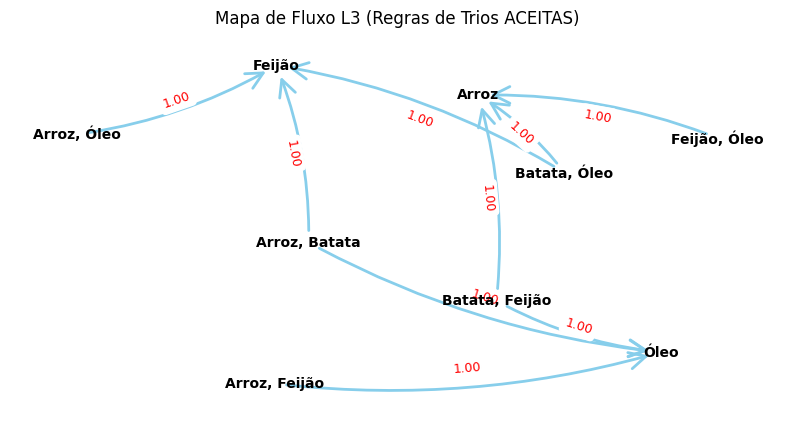

**Figura 2.14:** Representação visual (Grafo) das regras de associação de nível L3 aceitas.


In [12]:
# 4. Visualização do Grafo (Apenas para as Regras ACEITAS)
if not G_L3.edges():
    print("\nNenhuma regra L3 atingiu os critérios para exibição no grafo.")
else:
    plt.figure(figsize=(10, 5))
    # Seed fixo para garantir que o layout seja reproduzível
    pos = nx.spring_layout(G_L3, k=1.5, seed=41)
    
    # Desenho dos nós e labels
    nx.draw_networkx_labels(G_L3, pos, font_size=10, font_weight="bold")
    
    # Desenho das arestas com curvatura para evitar sobreposição de regras bidirecionais
    nx.draw_networkx_edges(G_L3, pos, arrowstyle='->', arrowsize=30, edge_color='skyblue', 
                        connectionstyle="arc3,rad=0.1", width=2)

    # Labels de Confiança (em vermelho) sobre as arestas
    edge_labels = {k: f"{v:.2f}" for k, v in nx.get_edge_attributes(G_L3, 'weight').items()}
    nx.draw_networkx_edge_labels(G_L3, pos, 
                                 edge_labels=edge_labels, font_color='red', font_size=9)

    plt.title("Mapa de Fluxo L3 (Regras de Trios ACEITAS)")
    plt.axis('off')
    plt.show()

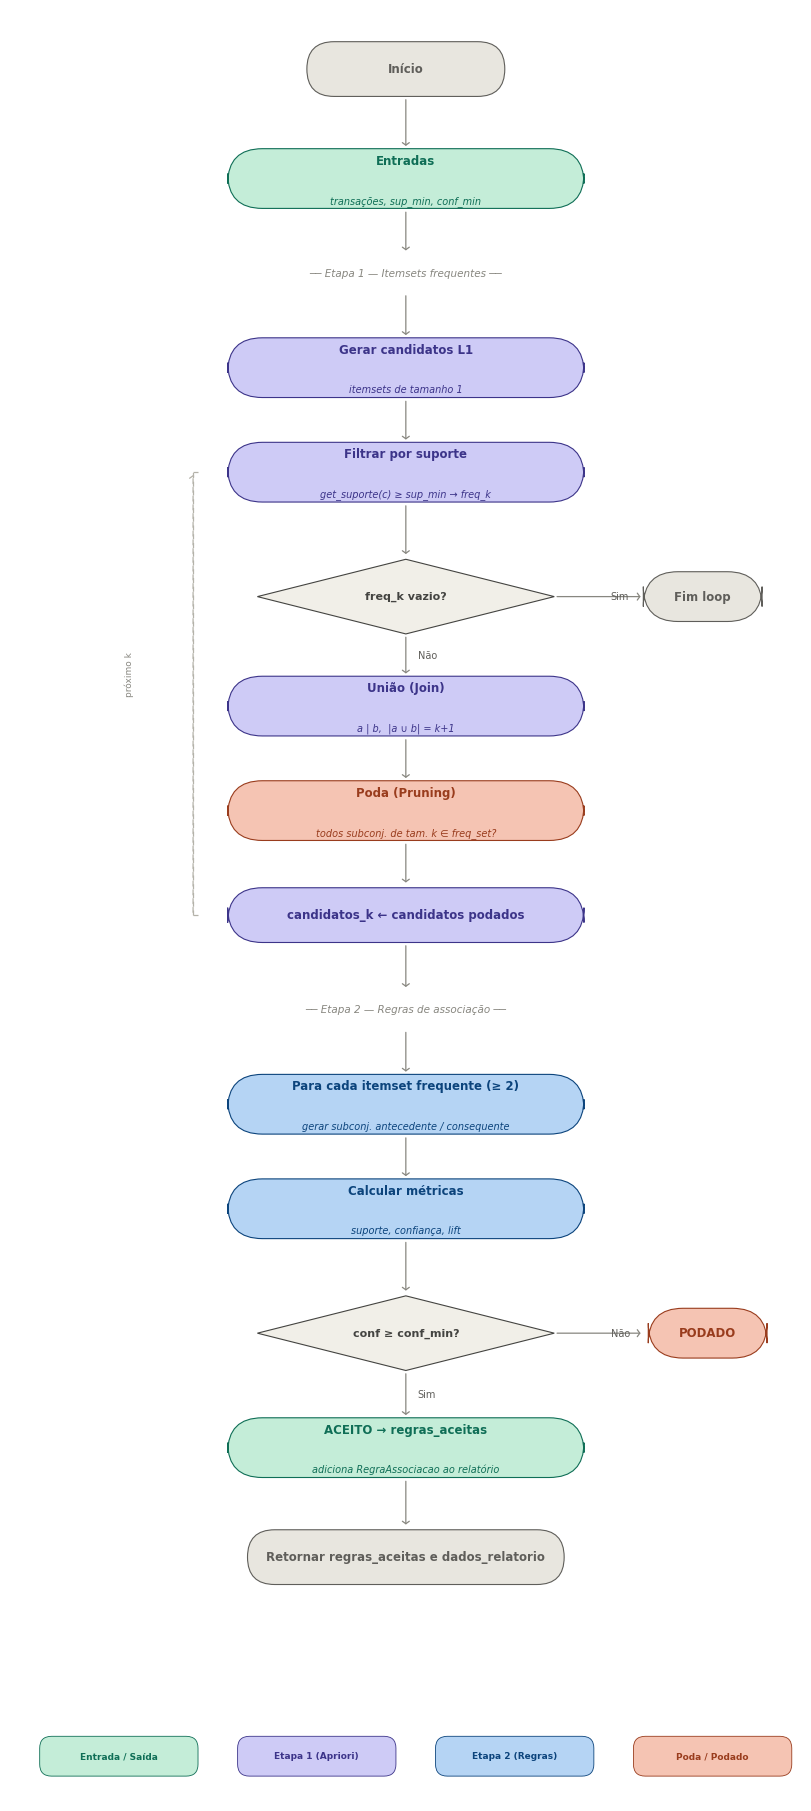

**Figura 15:** Fluxograma do Algoritmo Apriori — geração de itemsets frequentes e regras de associação.


In [ ]:
# @title { display-mode: "form" }
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import matplotlib.patheffects as pe

# ── Paleta de cores ────────────────────────────────────────────────────────────
COR = {
    "cinza":   ("#E8E6DF", "#5F5E5A"),   # (fundo, texto)  — início/fim
    "teal":    ("#C4EDD8", "#0F6E56"),   # entradas / aceito
    "roxo":    ("#CECBF6", "#3C3489"),   # etapa 1
    "azul":    ("#B5D4F4", "#0C447C"),   # etapa 2
    "coral":   ("#F5C4B3", "#993C1D"),   # poda/podado
    "decisao": ("#F1EFE8", "#444441"),   # losangos
}

fig, ax = plt.subplots(figsize=(8, 18))
ax.set_xlim(0, 8)
ax.set_ylim(0, 18)
ax.axis("off")
fig.patch.set_facecolor("white")


# ── Helpers ────────────────────────────────────────────────────────────────────
def caixa(ax, cx, cy, w, h, titulo, subtitulo=None,
          cor="cinza", raio=0.35, shape="rect"):
    """Desenha retângulo arredondado ou pílula."""
    fundo, texto = COR[cor]
    x, y = cx - w / 2, cy - h / 2

    if shape == "pill":
        raio = h / 2
    patch = FancyBboxPatch(
        (x, y), w, h,
        boxstyle=f"round,pad=0,rounding_size={raio}",
        linewidth=0.8,
        edgecolor=texto,
        facecolor=fundo,
        zorder=3,
    )
    ax.add_patch(patch)

    ty = cy + (0.18 if subtitulo else 0)
    ax.text(cx, ty, titulo, ha="center", va="center", fontsize=8.5,
            fontweight="bold", color=texto, zorder=4)
    if subtitulo:
        ax.text(cx, cy - 0.22, subtitulo, ha="center", va="center",
                fontsize=7, color=texto, zorder=4, style="italic")


def losango(ax, cx, cy, w, h, titulo):
    """Desenha losango de decisão."""
    fundo, texto = COR["decisao"]
    dx, dy = w / 2, h / 2
    pts = [(cx, cy + dy), (cx + dx, cy),
           (cx, cy - dy), (cx - dx, cy)]
    poly = plt.Polygon(pts, closed=True, linewidth=0.8,
                       edgecolor=texto, facecolor=fundo, zorder=3)
    ax.add_patch(poly)
    ax.text(cx, cy, titulo, ha="center", va="center",
            fontsize=8, fontweight="bold", color=texto, zorder=4)


def seta(ax, x1, y1, x2, y2, label=None, cor="#888780",
         dash=False, lw=0.9):
    """Desenha seta entre dois pontos."""
    ls = (0, (4, 3)) if dash else "-"
    ax.annotate(
        "", xy=(x2, y2), xytext=(x1, y1),
        arrowprops=dict(
            arrowstyle="->,head_width=0.25,head_length=0.18",
            color=cor, lw=lw, linestyle=ls,
        ),
        zorder=2,
    )
    if label:
        mx, my = (x1 + x2) / 2, (y1 + y2) / 2
        ax.text(mx + 0.12, my, label, fontsize=7, color="#5F5E5A",
                va="center", zorder=5)


def secao(ax, cy, texto):
    ax.text(4, cy, texto, ha="center", va="center",
            fontsize=7.5, color="#888780", style="italic", zorder=4)


# ── Largura padrão das caixas — ajuste este único valor ───────────────────────
W = 3.6

# ── Layout vertical (y decresce de cima para baixo) ────────────────────────────
# y começa em 17.4 e desce

# Início
caixa(ax, 4, 17.4, 2.0, 0.55, "Início", cor="cinza", shape="pill")
seta(ax, 4, 17.12, 4, 16.6)

# Entradas
caixa(ax, 4, 16.3, W, 0.6,
      "Entradas",
      "transações, sup_min, conf_min", cor="teal")
seta(ax, 4, 15.99, 4, 15.55)

# Seção 1
secao(ax, 15.35, "── Etapa 1 — Itemsets frequentes ──")
seta(ax, 4, 15.15, 4, 14.7)

# Candidatos L1
caixa(ax, 4, 14.4, W, 0.6,
      "Gerar candidatos L1",
      "itemsets de tamanho 1", cor="roxo")
seta(ax, 4, 14.09, 4, 13.65)

# Filtrar suporte
caixa(ax, 4, 13.35, W, 0.6,
      "Filtrar por suporte",
      "get_suporte(c) ≥ sup_min → freq_k", cor="roxo")
seta(ax, 4, 13.04, 4, 12.5)

# Decisão 1: freq_k vazio?
losango(ax, 4, 12.1, 3.0, 0.75, "freq_k vazio?")

# Sim → fim loop
seta(ax, 5.5, 12.1, 6.4, 12.1, label="Sim")
caixa(ax, 7.0, 12.1, 1.2, 0.5, "Fim loop", cor="cinza")

# Não ↓
seta(ax, 4, 11.72, 4, 11.3, label="Não")

# Join
caixa(ax, 4, 11.0, W, 0.6,
      "União (Join)",
      "a | b,  |a ∪ b| = k+1", cor="roxo")
seta(ax, 4, 10.69, 4, 10.25)

# Poda
caixa(ax, 4, 9.95, W, 0.6,
      "Poda (Pruning)",
      "todos subconj. de tam. k ∈ freq_set?", cor="coral")
seta(ax, 4, 9.64, 4, 9.2)

# Candidatos_k atualizados
caixa(ax, 4, 8.9, W, 0.55,
      "candidatos_k ← candidatos podados", cor="roxo")

# Seta de retorno (laço)
ax.annotate("", xy=(1.85, 13.35), xytext=(1.85, 8.9),
            arrowprops=dict(
                arrowstyle="->,head_width=0.25,head_length=0.18",
                color="#B4B2A9", lw=0.9,
                linestyle=(0, (4, 3)),
                connectionstyle="arc3,rad=0.0",
            ), zorder=2)
ax.plot([1.85, 1.85], [8.9, 13.35], color="#B4B2A9", lw=0.9,
        linestyle=(0, (4, 3)), zorder=2)
ax.plot([1.85, 1.9], [13.35, 13.35], color="#B4B2A9", lw=0.9,
        linestyle=(0, (4, 3)), zorder=2)
ax.plot([1.85, 1.9], [8.9, 8.9], color="#B4B2A9", lw=0.9,
        linestyle=(0, (4, 3)), zorder=2)
ax.text(1.2, 11.12, "próximo k", fontsize=6.5, color="#888780",
        ha="center", rotation=90)

seta(ax, 4, 8.62, 4, 8.15)

# Seção 2
secao(ax, 7.95, "── Etapa 2 — Regras de associação ──")
seta(ax, 4, 7.75, 4, 7.3)

# Iterar itemsets
caixa(ax, 4, 7.0, W, 0.6,
      "Para cada itemset frequente (≥ 2)",
      "gerar subconj. antecedente / consequente", cor="azul")
seta(ax, 4, 6.69, 4, 6.25)

# Calcular métricas
caixa(ax, 4, 5.95, W, 0.6,
      "Calcular métricas",
      "suporte, confiança, lift", cor="azul")
seta(ax, 4, 5.64, 4, 5.1)

# Decisão 2: conf >= conf_min?
losango(ax, 4, 4.7, 3.0, 0.75, "conf ≥ conf_min?")

# Não → Podado
seta(ax, 5.5, 4.7, 6.4, 4.7, label="Não")
caixa(ax, 7.05, 4.7, 1.2, 0.5, "PODADO", cor="coral")

# Sim ↓
seta(ax, 4, 4.32, 4, 3.85, label="Sim")

# Aceito
caixa(ax, 4, 3.55, W, 0.6,
      "ACEITO → regras_aceitas",
      "adiciona RegraAssociacao ao relatório", cor="teal")
seta(ax, 4, 3.24, 4, 2.75)

# Retornar
caixa(ax, 4, 2.45, 3.2, 0.55,
      "Retornar regras_aceitas e dados_relatorio",
      cor="cinza", shape="pill")

# ── Legenda ────────────────────────────────────────────────────────────────────
legendas = [
    ("Entrada / Saída",  COR["teal"][0],  COR["teal"][1]),
    ("Etapa 1 (Apriori)", COR["roxo"][0], COR["roxo"][1]),
    ("Etapa 2 (Regras)",  COR["azul"][0], COR["azul"][1]),
    ("Poda / Podado",     COR["coral"][0], COR["coral"][1]),
]
for i, (label, fundo, texto) in enumerate(legendas):
    bx = 0.3 + i * 2.0
    rect = FancyBboxPatch((bx, 0.25), 1.6, 0.4,
                          boxstyle="round,pad=0,rounding_size=0.12",
                          linewidth=0.6, edgecolor=texto,
                          facecolor=fundo, zorder=3)
    ax.add_patch(rect)
    ax.text(bx + 0.8, 0.45, label, ha="center", va="center",
            fontsize=6.5, fontweight="bold", color=texto, zorder=4)

plt.tight_layout(pad=0.3)
plt.savefig("images/apriori_fluxograma.svg", format="svg",
            bbox_inches="tight", dpi=200)
plt.savefig("images/apriori_fluxograma.png", format="png",
            bbox_inches="tight", dpi=200)
plt.show()

In [14]:
@dataclass
class RegraAssociacao:
    antecedente: frozenset
    consequente: frozenset
    suporte: float
    confianca: float
    lift: float = 0.0

def apriori(transacoes, sup_min, conf_min):
    # Dicionário para armazenar suportes já calculados: {itemset: valor}
    suportes_cache = {}
    n_transacoes = len(transacoes)

    def get_suporte(itemset):
        if itemset not in suportes_cache:
            count = sum(1 for t in transacoes if itemset.issubset(t))
            suportes_cache[itemset] = count / n_transacoes
        return suportes_cache[itemset]

    itens = sorted(set().union(*transacoes))
    frequentes = []
    # L1: Itens individuais
    candidatos_k = [frozenset([i]) for i in itens]

    # Etapa 1: Itemsets Frequentes (Geração e Poda)
    while candidatos_k:
        # Filtro de Suporte: Identifica quem é frequente no nível atual
        freq_k = [c for c in candidatos_k if get_suporte(c) >= sup_min]
        frequentes.extend(freq_k)
        
        if not freq_k: break
        
        # Gerar Candidatos para o próximo nível (k + 1)
        k_proximo = len(freq_k[0]) + 1
        freq_set = set(freq_k) # Set para busca rápida O(1)
        
        # união (Join)
        candidatos_brutos = {a | b for a, b in combinations(freq_k, 2) 
                             if len(a | b) == k_proximo}
        
        # PODA (Pruning): Só mantém o candidato se 
        # TODOS os seus subconjuntos de tamanho k forem frequentes
        candidatos_k = []
        for cand in candidatos_brutos:
            subconjuntos = [frozenset(c) for c in combinations(cand, k_proximo - 1)]
            if all(s in freq_set for s in subconjuntos):
                candidatos_k.append(cand)

    # Etapa 2: Regras de Associação
    regras_aceitas = []
    dados_relatorio = []

    for itemset in frequentes:
        if len(itemset) < 2: continue
        
        # Para cada subconjunto do itemset frequente 
        # (Gera regras muitos-para-um e muitos-para-muitos)
        for tam_ant in range(1, len(itemset)):
            for ant_tuple in combinations(itemset, tam_ant):
                ant = frozenset(ant_tuple)
                con = itemset - ant
                
                sup_total = get_suporte(itemset)
                sup_ant = get_suporte(ant)
                sup_con = get_suporte(con)
                
                # Cálculos de métricas
                conf = sup_total / sup_ant
                # Lift: Confiança dividida pelo suporte basal do consequente
                lift = conf / sup_con if sup_con > 0 else 0.0
                
                status = "ACEITO" if conf >= conf_min else "PODADO"
                regra = RegraAssociacao(ant, con, sup_total, conf, lift)
                
                if conf >= conf_min:
                    regras_aceitas.append(regra)
                
                # Formatação para o relatório
                ant_str = ", ".join(sorted(list(ant)))
                con_str = ", ".join(sorted(list(con)))

                dados_relatorio.append({
                    "Regra": f"{{{ant_str}}} → {{{con_str}}}",
                    "Suporte": f"{regra.suporte:.0%}",
                    "Confiança": f"{regra.confianca:.2f}",
                    "Lift": f"{regra.lift:.2f}",
                    "Status": status
                })
    
    return regras_aceitas, dados_relatorio

# --- Execução ---
regras_finais, relatorio_lista = apriori(transacoes, SUP_MIN, CONF_MIN)

# Criar DataFrame e ordenar decrescentemente pelo Lift (força da regra)
df_final = pd.DataFrame(relatorio_lista)
if not df_final.empty:
    df_final['Lift_Num'] = df_final['Lift'].astype(float)
    df_final = df_final.sort_values(by='Lift_Num', ascending=False).drop(columns=['Lift_Num'])

print(f"RELATÓRIO APRIORI COMPLETO (N={len(transacoes)}, CONF_MIN={CONF_MIN})\n")
Markdown(df_final.to_markdown(index=False, colalign=("center",) * len(df_final.columns)))

RELATÓRIO APRIORI COMPLETO (N=5, CONF_MIN=0.9)



**Tabela 2.17:** Relatório Consolidado de Regras de Associação (Algoritmo Apriori Completo).


|              Regra               |  Suporte  |  Confiança  |  Lift  |  Status  |
|:--------------------------------:|:---------:|:-----------:|:------:|:--------:|
|        {Queijo} → {Vinho}        |    40%    |      1      |  2.5   |  ACEITO  |
|        {Vinho} → {Queijo}        |    40%    |      1      |  2.5   |  ACEITO  |
|        {Batata} → {Óleo}         |    40%    |      1      |  1.67  |  ACEITO  |
|        {Óleo} → {Batata}         |    40%    |    0.67     |  1.67  |  PODADO  |
|     {Arroz, Óleo} → {Feijão}     |    60%    |      1      |  1.67  |  ACEITO  |
|     {Feijão} → {Arroz, Óleo}     |    60%    |      1      |  1.67  |  ACEITO  |
|        {Óleo} → {Feijão}         |    60%    |      1      |  1.67  |  ACEITO  |
|        {Feijão} → {Óleo}         |    60%    |      1      |  1.67  |  ACEITO  |
|       {Feijão} → {Batata}        |    40%    |    0.67     |  1.67  |  PODADO  |
|       {Batata} → {Feijão}        |    40%    |      1      |  1.67  |  ACEITO  |
|     {Arroz, Feijão} → {Óleo}     |    60%    |      1      |  1.67  |  ACEITO  |
|     {Óleo} → {Arroz, Feijão}     |    60%    |      1      |  1.67  |  ACEITO  |
|    {Feijão} → {Batata, Óleo}     |    40%    |    0.67     |  1.67  |  PODADO  |
|    {Batata, Óleo} → {Feijão}     |    40%    |      1      |  1.67  |  ACEITO  |
|    {Óleo} → {Batata, Feijão}     |    40%    |    0.67     |  1.67  |  PODADO  |
|    {Batata} → {Feijão, Óleo}     |    40%    |      1      |  1.67  |  ACEITO  |
|     {Arroz, Batata} → {Óleo}     |    40%    |      1      |  1.67  |  ACEITO  |
|     {Arroz, Óleo} → {Batata}     |    40%    |    0.67     |  1.67  |  PODADO  |
|     {Batata} → {Arroz, Óleo}     |    40%    |      1      |  1.67  |  ACEITO  |
|     {Óleo} → {Arroz, Batata}     |    40%    |    0.67     |  1.67  |  PODADO  |
| {Arroz, Batata, Óleo} → {Feijão} |    40%    |      1      |  1.67  |  ACEITO  |
| {Arroz, Feijão, Óleo} → {Batata} |    40%    |    0.67     |  1.67  |  PODADO  |
| {Arroz, Batata} → {Feijão, Óleo} |    40%    |      1      |  1.67  |  ACEITO  |
| {Feijão} → {Arroz, Batata, Óleo} |    40%    |    0.67     |  1.67  |  PODADO  |
| {Feijão, Óleo} → {Arroz, Batata} |    40%    |    0.67     |  1.67  |  PODADO  |
| {Batata, Óleo} → {Arroz, Feijão} |    40%    |      1      |  1.67  |  ACEITO  |
| {Batata, Feijão} → {Arroz, Óleo} |    40%    |      1      |  1.67  |  ACEITO  |
| {Arroz, Óleo} → {Batata, Feijão} |    40%    |    0.67     |  1.67  |  PODADO  |
|    {Batata} → {Arroz, Feijão}    |    40%    |      1      |  1.67  |  ACEITO  |
|    {Feijão} → {Arroz, Batata}    |    40%    |    0.67     |  1.67  |  PODADO  |
|    {Feijão, Óleo} → {Batata}     |    40%    |    0.67     |  1.67  |  PODADO  |
|    {Batata, Feijão} → {Óleo}     |    40%    |      1      |  1.67  |  ACEITO  |
|    {Arroz, Batata} → {Feijão}    |    40%    |      1      |  1.67  |  ACEITO  |
| {Batata} → {Arroz, Feijão, Óleo} |    40%    |      1      |  1.67  |  ACEITO  |
| {Óleo} → {Arroz, Batata, Feijão} |    40%    |    0.67     |  1.67  |  PODADO  |
|    {Arroz, Feijão} → {Batata}    |    40%    |    0.67     |  1.67  |  PODADO  |
| {Arroz, Batata, Feijão} → {Óleo} |    40%    |      1      |  1.67  |  ACEITO  |
| {Arroz, Feijão} → {Batata, Óleo} |    40%    |    0.67     |  1.67  |  PODADO  |
|         {Óleo} → {Arroz}         |    60%    |      1      |  1.25  |  ACEITO  |
|     {Arroz} → {Feijão, Óleo}     |    60%    |    0.75     |  1.25  |  PODADO  |
|        {Batata} → {Arroz}        |    40%    |      1      |  1.25  |  ACEITO  |
|        {Arroz} → {Batata}        |    40%    |     0.5     |  1.25  |  PODADO  |
|        {Feijão} → {Arroz}        |    60%    |      1      |  1.25  |  ACEITO  |
|        {Arroz} → {Feijão}        |    60%    |    0.75     |  1.25  |  PODADO  |
|     {Feijão, Óleo} → {Arroz}     |    60%    |      1      |  1.25  |  ACEITO  |
|         {Arroz} → {Óleo}         |    60%    |    0.75     |  1.25  |  PODADO  |
|     {Arroz} → {Batata, Óleo}     |    40%    |     0.5     |  1.25  |  PODADO  |
|     {Batata, Óleo} → {Arroz}     |    40%    |      1      |  1.25  |  ACEITO  |
|    {Arroz} → {Batata, Feijão}    |    40%    |     0.5     |  1.25  |  PODADO  |
|    {Batata, Feijão} → {Arroz}    |    40%    |      1      |  1.25  |  ACEITO  |
| {Arroz} → {Batata, Feijão, Óleo} |    40%    |     0.5     |  1.25  |  PODADO  |
| {Batata, Feijão, Óleo} → {Arroz} |    40%    |      1      |  1.25  |  ACEITO  |

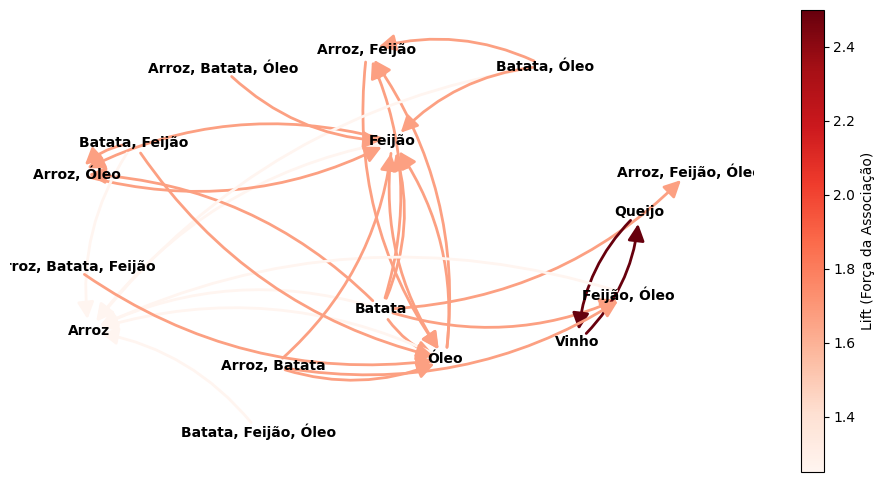

**Figura 2.16:** Grafo de Influência: A intensidade da cor (Reds) indica o valor estratégico do Lift.


In [15]:
# --- Grafo de Lift (Apenas regras ACEITAS) ---
G_final = nx.DiGraph()
for r in regras_finais:
    G_final.add_edge(", ".join(sorted(r.antecedente)), 
                     ", ".join(sorted(r.consequente)), weight=r.lift)

if not G_final.edges():
    print("\nNenhuma regra atingiu os critérios para exibição no grafo.")
else:
    plt.figure(figsize=(12, 6))
    pos = nx.spring_layout(G_final, k=2.5, seed=1)
    lifts = [G_final[u][v]['weight'] for u, v in G_final.edges()]
    
    nx.draw_networkx_labels(G_final, pos, font_size=10, font_weight='bold')
    
    # Mapeamento de cores baseado no Lift
    sm = plt.cm.ScalarMappable(cmap=plt.cm.Reds, 
                               norm=plt.Normalize(vmin=min(lifts), vmax=max(lifts)))
    
    nx.draw_networkx_edges(G_final, pos, edge_color=lifts, edge_cmap=plt.cm.Reds, width=2, 
                           arrowsize=25, connectionstyle="arc3,rad=0.2")
    
    plt.colorbar(sm, ax=plt.gca(), label='Lift (Força da Associação)')
    plt.axis('off')
    plt.show()

In [16]:
!pip install mlxtend -q --no-cache-dir 2>/dev/null

In [17]:
 
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

# 1. Dados de exemplo
dataset = [["Arroz", "Feijão", "Óleo"], 
           ["Queijo", "Vinho"], 
           ["Arroz", "Feijão", "Batata", "Óleo"], 
           ["Arroz", "Água", "Vinho", "Queijo"], 
           ["Arroz", "Feijão", "Batata", "Óleo"]]

# 2. Processamento MLxtend
te = TransactionEncoder()
te_ary = te.fit(dataset).transform(dataset)
df = pd.DataFrame(te_ary, columns=te.columns_)

frequent_itemsets = apriori(df, min_support=0.4, use_colnames=True)
regras = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.9)

# --- RELATÓRIO ---

# 3. Preparação do DataFrame Final
df_final = regras[['antecedents', 'consequents', 'support', 'confidence', 'lift']].copy()

# ORDENAÇÃO: Sempre antes de formatar como string para garantir precisão matemática
df_final = df_final.sort_values(by='lift', ascending=False)

# LIMPEZA E JUNÇÃO: Criando a coluna única "Regra"
df_final['Regra'] = df_final.apply(
    lambda x: f"{{{', '.join(list(x['antecedents']))}}} → \
        {{{', '.join(list(x['consequents']))}}}", 
    axis=1
)

# SELEÇÃO DE COLUNAS: Mantendo apenas a Regra e as métricas
df_final = df_final[['Regra', 'support', 'confidence', 'lift']]
df_final.columns = ['Regra', 'Suporte', 'Confiança', 'Lift']

# --- FORMATAÇÃO VISUAL ---
df_final['Suporte'] = df_final['Suporte'].map('{:.1%}'.format)
df_final['Confiança'] = df_final['Confiança'].map('{:.2f}'.format)
df_final['Lift'] = df_final['Lift'].map('{:.2f}'.format)

# 4. Exibição do Relatório
Markdown(df_final.to_markdown(index=False, colalign=("center",) * len(df_final.columns)))

**Tabela 2.18:** Regras de Associação Geradas com a Biblioteca MLxtend.


|                  Regra                   |  Suporte  |  Confiança  |  Lift  |
|:----------------------------------------:|:---------:|:-----------:|:------:|
|        {Queijo} →         {Vinho}        |   40.0%   |      1      |  2.5   |
|        {Vinho} →         {Queijo}        |   40.0%   |      1      |  2.5   |
|        {Óleo} →         {Feijão}         |   60.0%   |      1      |  1.67  |
|        {Feijão} →         {Óleo}         |   60.0%   |      1      |  1.67  |
|        {Batata} →         {Óleo}         |   40.0%   |      1      |  1.67  |
|       {Batata} →         {Feijão}        |   40.0%   |      1      |  1.67  |
|    {Batata} →         {Arroz, Feijão}    |   40.0%   |      1      |  1.67  |
|     {Arroz, Batata} →         {Óleo}     |   40.0%   |      1      |  1.67  |
|    {Arroz, Batata} →         {Feijão}    |   40.0%   |      1      |  1.67  |
|    {Óleo, Batata} →         {Feijão}     |   40.0%   |      1      |  1.67  |
|     {Óleo} →         {Arroz, Feijão}     |   60.0%   |      1      |  1.67  |
|     {Arroz, Feijão} →         {Óleo}     |   60.0%   |      1      |  1.67  |
|     {Arroz, Óleo} →         {Feijão}     |   60.0%   |      1      |  1.67  |
|     {Batata} →         {Arroz, Óleo}     |   40.0%   |      1      |  1.67  |
| {Batata, Feijão} →         {Arroz, Óleo} |   40.0%   |      1      |  1.67  |
| {Arroz, Óleo, Batata} →         {Feijão} |   40.0%   |      1      |  1.67  |
| {Arroz, Batata, Feijão} →         {Óleo} |   40.0%   |      1      |  1.67  |
| {Arroz, Batata} →         {Óleo, Feijão} |   40.0%   |      1      |  1.67  |
| {Batata} →         {Arroz, Óleo, Feijão} |   40.0%   |      1      |  1.67  |
|     {Feijão} →         {Arroz, Óleo}     |   60.0%   |      1      |  1.67  |
|    {Batata, Feijão} →         {Óleo}     |   40.0%   |      1      |  1.67  |
|    {Batata} →         {Óleo, Feijão}     |   40.0%   |      1      |  1.67  |
| {Óleo, Batata} →         {Arroz, Feijão} |   40.0%   |      1      |  1.67  |
|     {Óleo, Batata} →         {Arroz}     |   40.0%   |      1      |  1.25  |
|        {Feijão} →         {Arroz}        |   60.0%   |      1      |  1.25  |
|         {Óleo} →         {Arroz}         |   60.0%   |      1      |  1.25  |
|        {Batata} →         {Arroz}        |   40.0%   |      1      |  1.25  |
|    {Batata, Feijão} →         {Arroz}    |   40.0%   |      1      |  1.25  |
|     {Óleo, Feijão} →         {Arroz}     |   60.0%   |      1      |  1.25  |
| {Óleo, Batata, Feijão} →         {Arroz} |   40.0%   |      1      |  1.25  |

## Referências do Capítulo


AGRAWAL, Rakesh; IMIELIŃSKI, Tomasz; SWAMI, Arun. **Mining association rules between sets of items in large databases**. 1993.

FRANK, Eibe; HALL, Mark A.; WITTEN, Ian H. **The {WEKA} Workbench. Online Appendix for "Data Mining: Practical Machine Learning Tools and Techniques"**. Morgan Kaufmann, 2016.

HAN, J.; KAMBER, M. **Data Mining: Concepts and Techniques**. Morgan Kaufmann Publishers, 2008.

PADHY, N. P. **Artificial Intelligence and Intelligent Systems**. Oxford University Press, 2010.

QUINLAN, R. **Induction of Decision Trees**. 1986.

ROCHA, Miguel; CORTEZ, Paulo; NEVES, Jos{\'e} M. **Sem titulo**. Lisboa, Editora de Inform{\'a}tica, 2008.

TAN, P.N.; STEINBACH, M.; KUMAR, V. **Introdução ao Data Mining Mineração de Dados**. Editora Ciência Moderna Ltda., 2009.

WITTEN, I. H.; FRANK, E. **Data Mining: Practical Machine Learning Tools and Techniques**. Morgan Kaufmann Publishers, 2005.